# Demonstration of KU

Consider the following setup: a Bernoulli bandit with 2 arms. Arm $i ∈ \{1,2\}$ gives reward 1 with probability $p_i$ and reward 0 otherwise. Each episode consists of a single interaction: the agent picks an arm, it observes the outcome, end of episode.

We know that $p_1 ∈ [0.3, 0.7]$ and $p_2 ∈ [0.4, 0.8]$, but nothing else. The values of $p_1$ and $p_2$ are chosen anew at the beginning of each episode, by an unknown (potentially adversarial) mechanism. The agent has KU over $p_1$ and $p_2$. It cannot assign a meaningful prior, and it cannot learn over multiple episodes.

The ranges of reward probabilities span a square in the space of possible environments. We consider the convex hull of this space, which is given by the corners of the square. In all of the following, it is sufficient to consider only these corners, as every point within the square is given by some convex combination of the corners.

A classical agent cannot represent the available information. It has to settle on a single $(p_1,p_2)$ pair as a prior. Any point within the allowed range is an equally valid choice. We will consider four different classical agents, whose hypotheses are the four corners of the convex hull of possible environments. Depending on their initialisation, they will either pull arm 1 or arm 2.

An IB agent can represent KU, so we only need a single agent. It will always pull arm 2, because it has a better worst-case expected reward.

We test all agent candidates on four possible environments: those whose reward probabilities are fixed at the four corners of the convex hull. (In these cases, an agent could of course learn the probabilities over time. A more realistic scenario would be when the reward probabilities change between episodes, potentially chosen by an adversary who is trying to confuse/exploit the agent. By setting up the agent in a way where it does not even try to learn the probabilities, we effectively get the same situation, without having to implement an adversary.)

We record the regret of each agent/environment combination. We will find that the worst-case regret of the IB agent is smaller the worst-case regret of the classical agent. This is exactly what we want. The IB agent provides some guarantees regarding the worst-case outcome.

(The IB agent achieves the worst-case guarantees at the cost of average performance being potentially worst. At least in this case, we cannot define an average performance though, because that would require us to assign a probability to environments and to classical agent initialisations, neither of which is defined.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.environments import BernoulliBanditEnvironment
from ibrl.agents import InfraBayesianAgent, DiscreteBayesianAgent
from ibrl.infrabayesian import AMeasure,Infradistribution,MultiBernoulliWorldModel

In [2]:
# Possible ranges for reward probabilities
range1 = (0.3,0.7)
range2 = (0.4,0.8)

# Convex hull of possible environments
corners = [
    [range1[0], range2[0]],
    [range1[1], range2[0]],
    [range1[0], range2[1]],
    [range1[1], range2[1]]
]

In [3]:
# Wrapper for non-learning classical agent
class BayesianAgent(DiscreteBayesianAgent):
    def __init__(self, p1, p2, *args, **kwargs):
        super().__init__(num_hypotheses=2, *args, **kwargs)
        self.hypotheses = np.array([  # shape (num_hypotheses,num_outcomes=2)
            [1 - p1, p1],  # hypothesis 1 (for arm 1)
            [1 - p2, p2]   # hypothesis 2 (for arm 2)
        ])

    def reset(self):
        super().reset()
        self.prior = np.eye(self.num_hypotheses)  # assign i-th hypothesis to i-th arm with 100% probability

In [4]:
agent_options = {
    "num_actions": 2,
    "epsilon": 0.0  # disable exploration
}
env_options = {
    "num_actions": 2,
}
sim_options = {
    "num_steps":   100,
    "num_runs":    50,
}

In [5]:
wm = MultiBernoulliWorldModel(2)
classical_results = []
ib_results = []
# Iterate over environments
for env_probs in corners:
    # Iterate over classical agents
    for agent_probs in corners:
        env = BernoulliBanditEnvironment(probs=env_probs, **env_options)
        agent = BayesianAgent(p1=agent_probs[0], p2=agent_probs[1], **agent_options)
        classical_results.append(simulate(env, agent, sim_options))

    # Single IB agent
    env = BernoulliBanditEnvironment(probs=env_probs, **env_options)
    agent = InfraBayesianAgent(hypotheses=[Infradistribution([
        AMeasure(wm.make_params(np.array([[1-p1,p1],[1-p2,p2]]))) for p1,p2 in corners
    ], wm)], **agent_options)
    ib_results.append(simulate(env, agent, sim_options))

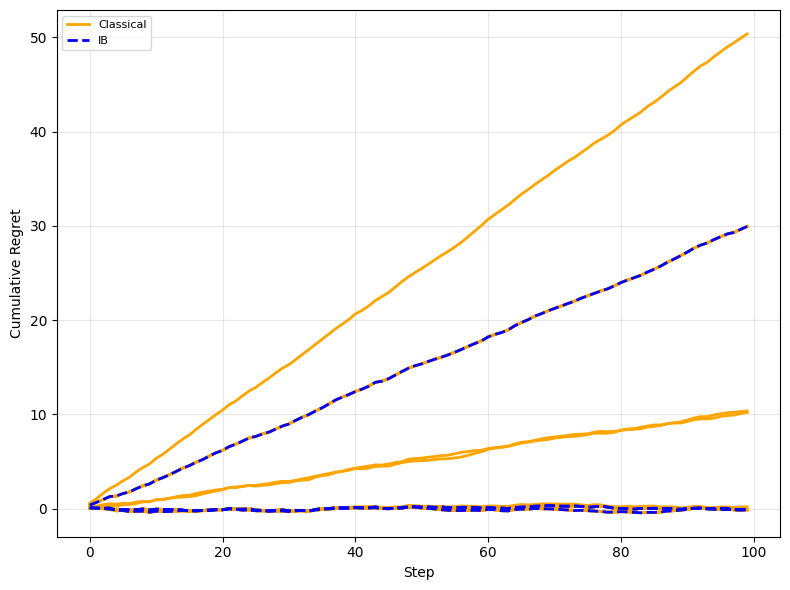

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for i,result in enumerate(classical_results):
    avg = result["average_reward"][0, :]
    regret = np.cumsum(result["optimal_reward"] - avg)
    ax.plot(regret, linewidth=2, color="orange", label="Classical" if i==0 else None)
for i,result in enumerate(ib_results):
    avg = result["average_reward"][0, :]
    regret = np.cumsum(result["optimal_reward"] - avg)
    ax.plot(regret, linewidth=2, color="blue", ls="--", label="IB" if i==0 else None)
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Regret")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Here we plot all agent/environment combinations together. We are mainly interested in the worst-case regret of each agent, i.e. the line with the steepest slope.

The worst-case regret of the IB agent 0.3 per step (the case where arm 1 would have given expected reward 0.7, but the agent sticks with arm 2 and gets 0.4).

For the classical agent, the worst-case regret is 0.5 per step (arm 2 would have given expected reward 0.8, but the agent believes arm 1 is better, but arm 1 actually gives 0.3).